In [61]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [62]:
df = pd.read_csv("penguins_size.csv")

In [63]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [64]:
df['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [66]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [67]:
df.sex.unique()

array(['MALE', 'FEMALE', nan, '.'], dtype=object)

In [68]:
df["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

### EDA :

#### Missing Data 

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [70]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [71]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [72]:
df = df.dropna()

In [73]:
df.isnull().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [74]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [75]:
df["species"].value_counts()

species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

In [76]:
df["island"].value_counts()

island
Biscoe       164
Dream        123
Torgersen     47
Name: count, dtype: int64

In [77]:
df["sex"].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [78]:
df[df["sex"] == '.']

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


In [79]:
df[df['species'] == 'Gentoo'].groupby('sex').describe().transpose()

sex                           .       FEMALE         MALE
culmen_length_mm  count     1.0    58.000000    61.000000
                  mean     44.5    45.563793    49.473770
                  std       NaN     2.051247     2.720594
                  min      44.5    40.900000    44.400000
                  25%      44.5    43.850000    48.100000
                  50%      44.5    45.500000    49.500000
                  75%      44.5    46.875000    50.500000
                  max      44.5    50.500000    59.600000
culmen_depth_mm   count     1.0    58.000000    61.000000
                  mean     15.7    14.237931    15.718033
                  std       NaN     0.540249     0.741060
                  min      15.7    13.100000    14.100000
                  25%      15.7    13.800000    15.200000
                  50%      15.7    14.250000    15.700000
                  75%      15.7    14.600000    16.100000
                  max      15.7    15.500000    17.300000
flipper_length_mm count     1.0    58.000000    61.000000
                  mean    217.0   212.706897   221.540984
                  std       NaN     3.897856     5.673252
                  min     217.0   203.000000   208.000000
                  25%     217.0   210.000000   218.000000
                  50%     217.0   212.000000   221.000000
                  75%     217.0   215.000000   225.000000
                  max     217.0   222.000000   231.000000
body_mass_g       count     1.0    58.000000    61.000000
                  mean   4875.0  4679.741379  5484.836066
                  std       NaN   281.578294   313.158596
                  min    4875.0  3950.000000  4750.000000
                  25%    4875.0  4462.500000  5300.000000
                  50%    4875.0  4700.000000  5500.000000
                  75%    4875.0  4875.000000  5700.000000
                  max    4875.0  5200.000000  6300.000000

In [80]:
df['sex'] = df['sex'].replace('.','MALE')

In [81]:
df['sex'].value_counts()

sex
MALE      169
FEMALE    165
Name: count, dtype: int64

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


### Visualization

In [83]:
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

<Axes: xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

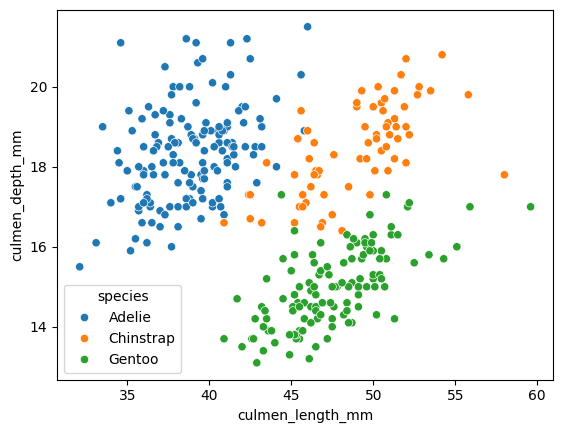

In [84]:
sns.scatterplot(x ='culmen_length_mm',y = 'culmen_depth_mm' , data = df, hue = 'species' )

* It seems data is separable. So model can able to separate well. 

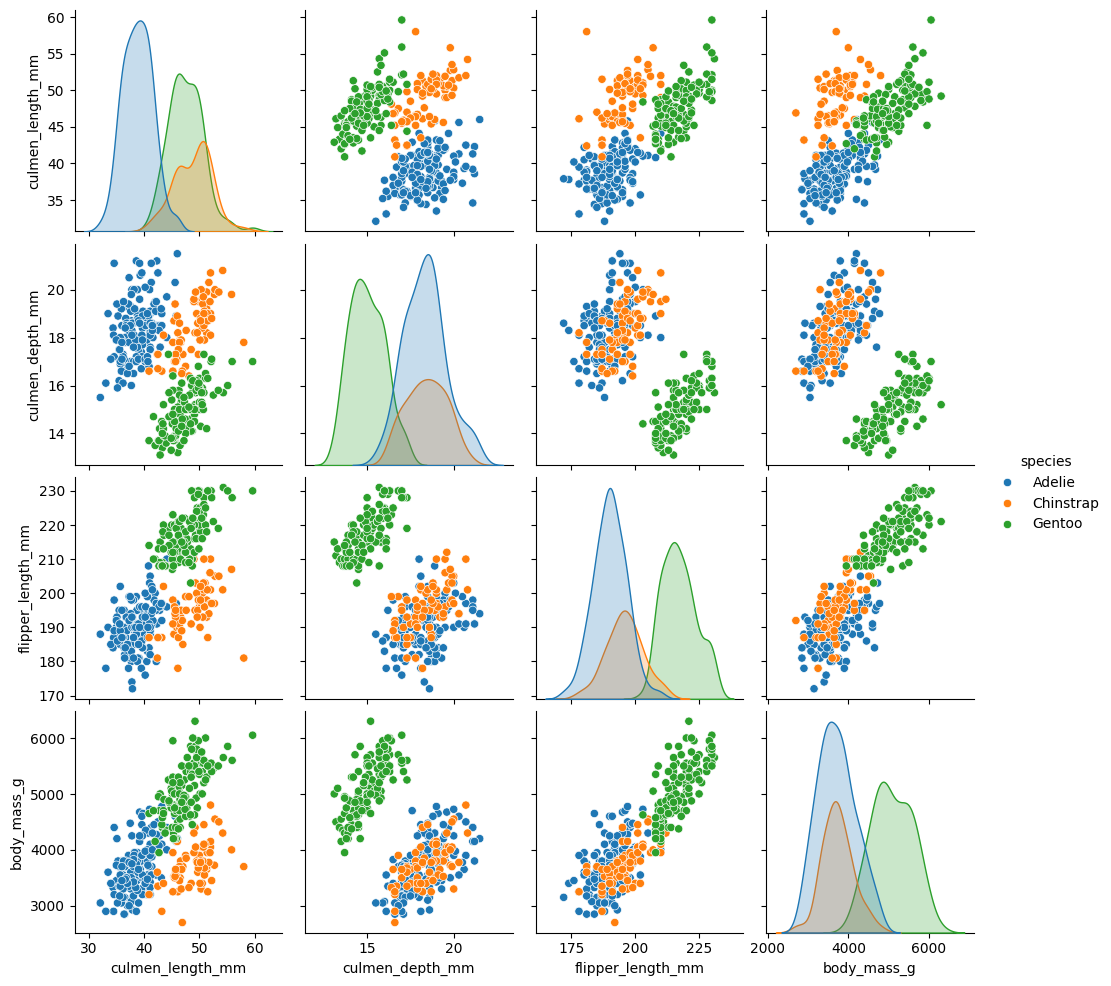

In [85]:
sns.pairplot(df,hue = 'species')

* It seems  culmin length and culmin depth is a  dominant features to separate the data.
   

<Axes: xlabel='species', ylabel='culmen_length_mm'>

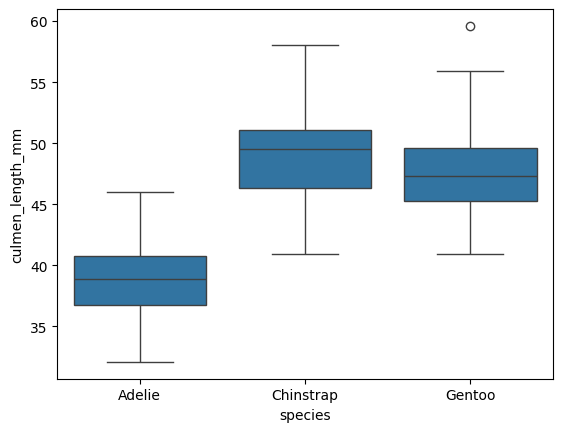

In [86]:
sns.boxplot(x = "species",y = "culmen_length_mm", data = df)

<Axes: xlabel='species', ylabel='culmen_length_mm'>

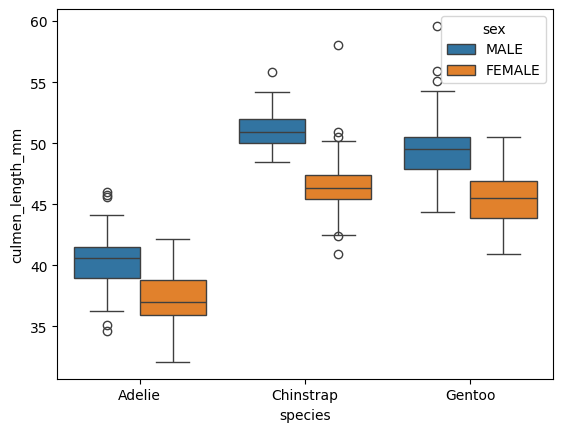

In [87]:

sns.boxplot(x = "species",y = "culmen_length_mm", data = df, hue = 'sex')

####  Feature Engineering

In [88]:
pd.get_dummies(df)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,True,False,False,False,False,True,False,True
1,39.5,17.4,186.0,3800.0,True,False,False,False,False,True,True,False
2,40.3,18.0,195.0,3250.0,True,False,False,False,False,True,True,False
4,36.7,19.3,193.0,3450.0,True,False,False,False,False,True,True,False
5,39.3,20.6,190.0,3650.0,True,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,True,True,False,False,True,False
340,46.8,14.3,215.0,4850.0,False,False,True,True,False,False,True,False
341,50.4,15.7,222.0,5750.0,False,False,True,True,False,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,True,True,False,False,True,False


In [89]:
pd.get_dummies(df.drop('species', axis = 1))

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,False,False,True,False,True
1,39.5,17.4,186.0,3800.0,False,False,True,True,False
2,40.3,18.0,195.0,3250.0,False,False,True,True,False
4,36.7,19.3,193.0,3450.0,False,False,True,True,False
5,39.3,20.6,190.0,3650.0,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,True,False,False,True,False
340,46.8,14.3,215.0,4850.0,True,False,False,True,False
341,50.4,15.7,222.0,5750.0,True,False,False,False,True
342,45.2,14.8,212.0,5200.0,True,False,False,True,False


In [90]:
pd.get_dummies(df.drop('species', axis = 1), drop_first= True)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,False
340,46.8,14.3,215.0,4850.0,False,False,False
341,50.4,15.7,222.0,5750.0,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,False


In [91]:
X = pd.get_dummies(df.drop('species', axis = 1), drop_first= True)
y = df['species']

In [92]:
print(y)

0      Adelie
1      Adelie
2      Adelie
4      Adelie
5      Adelie
        ...  
338    Gentoo
340    Gentoo
341    Gentoo
342    Gentoo
343    Gentoo
Name: species, Length: 334, dtype: object


#####  In decision trees dont need to scale (we are not using any distance), because we are just comparing the data. 

### Train Test split 

In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.3, random_state= 101)

### Decision Tree classifier

In [95]:
from sklearn.tree import DecisionTreeClassifier

In [96]:
model = DecisionTreeClassifier()

In [97]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [98]:
base_pred = model.predict(X_test)

In [99]:
print(base_pred)

['Chinstrap' 'Gentoo' 'Adelie' 'Chinstrap' 'Gentoo' 'Chinstrap' 'Adelie'
 'Gentoo' 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Gentoo'
 'Gentoo' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Gentoo'
 'Chinstrap' 'Adelie' 'Adelie' 'Adelie' 'Adelie' 'Chinstrap' 'Gentoo'
 'Adelie' 'Chinstrap' 'Gentoo' 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie'
 'Chinstrap' 'Adelie' 'Gentoo' 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie'
 'Gentoo' 'Adelie' 'Adelie' 'Chinstrap' 'Chinstrap' 'Chinstrap' 'Adelie'
 'Adelie' 'Adelie' 'Adelie' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie'
 'Chinstrap' 'Chinstrap' 'Gentoo' 'Adelie' 'Chinstrap' 'Gentoo' 'Adelie'
 'Adelie' 'Chinstrap' 'Gentoo' 'Chinstrap' 'Chinstrap' 'Gentoo' 'Gentoo'
 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo' 'Gentoo'
 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Gentoo'
 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie'
 'Chinstrap' 'Gentoo' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie' 'Gentoo']


###  Performance of the model:

In [102]:
from sklearn.metrics import confusion_matrix, classification_report

In [103]:
confusion_matrix(y_test, base_pred)

array([[39,  2,  0],
       [ 4, 19,  0],
       [ 0,  0, 37]])


This is a **3×3 matrix**, meaning we are dealing with a **3-class classification problem**.

---

#### Structure
- **Rows** = Actual / True classes (`y_test`)
- **Columns** = Predicted classes (`base_pred`)
- Entry `[i, j]` = Number of samples whose true class = *i* but were predicted as class = *j*

---

#### Row-wise Interpretation

1. **True Class = 0**  
   - 39 correctly predicted as class 0  
   - 2 misclassified as class 1  
   - 0 misclassified as class 2  
    High accuracy for class 0.

2. **True Class = 1**  
   - 4 misclassified as class 0  
   - 19 correctly predicted as class 1  
   - 0 misclassified as class 2  
   Some confusion between class 1 and class 0.

3. **True Class = 2**  
   - 37 correctly predicted as class 2  
   - 0 misclassified  
    Perfect classification for class 2.

---

#### Overall Performance
- **Correct predictions =** 39 + 19 + 37 = **95**  
- **Total samples =** 101  
- **Accuracy =** 95 / 101 ≈ **94%**

---

 The model performs very well overall, with only small confusion between class 0 and class 1.
 * In total there are 6 miss classification.


In [108]:
print(classification_report(y_test, base_pred))

              precision    recall  f1-score   support

      Adelie       0.91      0.95      0.93        41
   Chinstrap       0.90      0.83      0.86        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.94       101
   macro avg       0.94      0.93      0.93       101
weighted avg       0.94      0.94      0.94       101



In [109]:
model.feature_importances_

array([0.32352044, 0.04203954, 0.54282921, 0.01325074, 0.0681854 ,
       0.01017467, 0.        ])


---

#### What this means
- Each number corresponds to the **importance score** of a feature used by the model.
- Higher values indicate that the feature contributes more to the model’s predictions.
- The values are **normalized to sum to 1.0**.

---

#### Feature-wise breakdown

| Feature   | Importance | Interpretation |
|-----------|------------|----------------|
| Feature 1 | **0.324**  | Second most important |
| Feature 2 | 0.042      | Small contribution |
| Feature 3 | **0.543**  | Most important feature (over 50% of influence) |
| Feature 4 | 0.013      | Negligible contribution |
| Feature 5 | 0.068      | Moderate contribution |
| Feature 6 | 0.010      | Very little contribution |
| Feature 7 | 0.000      | Not used by the model |

---

#### Insights
- The model **mainly relies on Feature 3 and Feature 1**, together contributing ~87% of predictive power.  
- Feature 5 adds some influence (~7%).  
- Features 2, 4, and 6 contribute very little.  
- Feature 7 was **completely unused** by the model.

---

 This tells us which features are driving the model’s decisions and which features might be less relevant.


Note :
* we can change the random state and check, ie: perform the cross validation. 

In [111]:
X.columns

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'island_Dream', 'island_Torgersen', 'sex_MALE'],
      dtype='object')

In [112]:
pd.DataFrame(index = X.columns, data =  model.feature_importances_, columns = ["Feature Importance"])

,Feature Importance
culmen_length_mm,0.323520
culmen_depth_mm,0.042040
flipper_length_mm,0.542829
body_mass_g,0.013251
island_Dream,0.068185
island_Torgersen,0.010175
sex_MALE,0.000000


### Visualizing the tree

In [113]:
from sklearn.tree import plot_tree

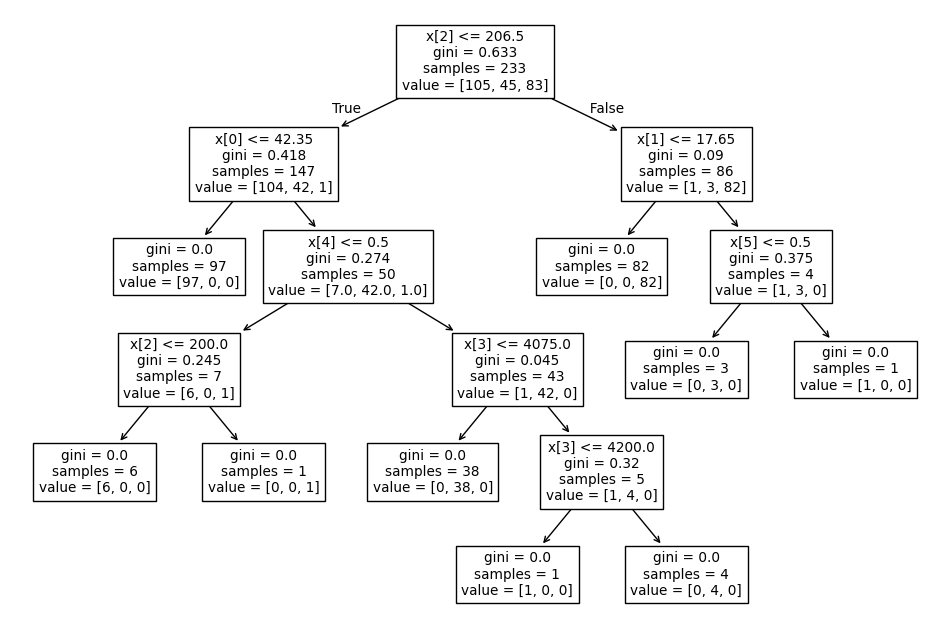

In [115]:
plt.figure(figsize=(12,8))
plot_tree(model)
plt.show()

* it has taken the cflipper length as the root node. 

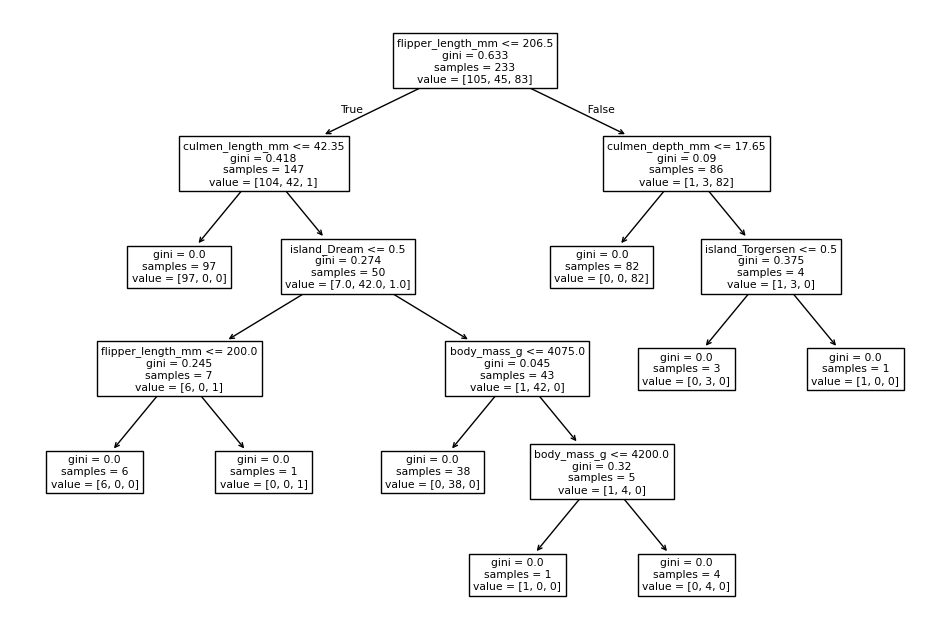

In [117]:
plt.figure(figsize=(12,8))
plot_tree(model, feature_names= X.columns)
plt.show()

In [118]:
# In root node why sample is 233 
0.7*len(df)


233.79999999999998

### Reporting Model results

In [120]:
def report_result(model):
    model_preds = model.predict(X_test)
    print(classification_report(y_test, model_preds))
    print('\n')
    plt.figure(figsize=(12,8))
    plot_tree(model, filled = True, feature_names=X.columns)

### Understanding the parameters 

In [122]:
#help(DecisionTreeClassifier)

In [125]:
# We can fix the no of branches or level (like that)
pruned_tree = DecisionTreeClassifier(max_depth= 2 )
pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

              precision    recall  f1-score   support

      Adelie       0.97      0.88      0.92        41
   Chinstrap       0.81      0.96      0.88        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.94       101
   macro avg       0.93      0.94      0.93       101
weighted avg       0.95      0.94      0.94       101





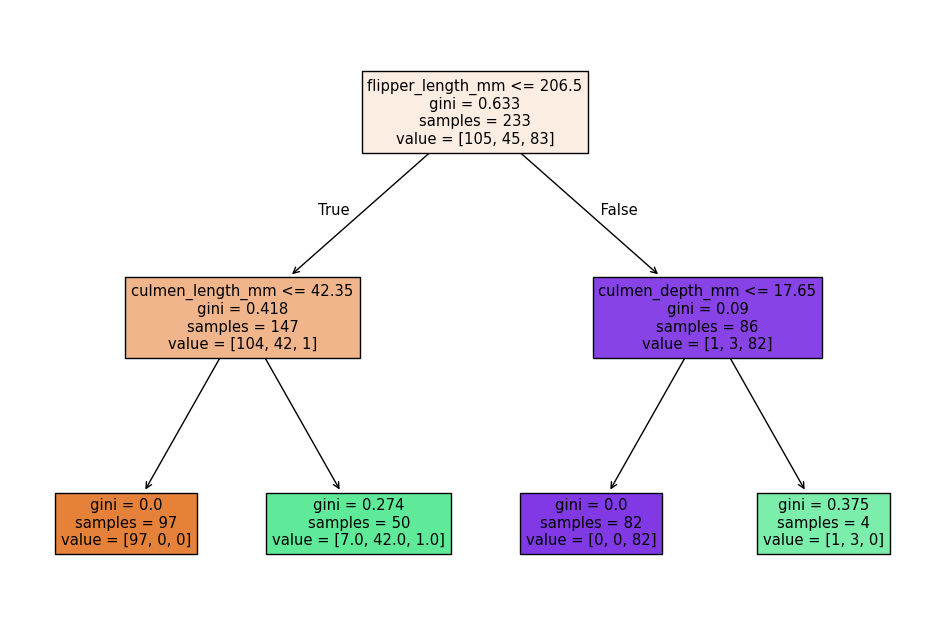

In [127]:
report_result(pruned_tree) # report and plot for this pruned tree model

##### Max leaf nodes (nodes which dont have further branches)

In [132]:
pruned_tree = DecisionTreeClassifier(max_leaf_nodes=3)

In [133]:
pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=3)

              precision    recall  f1-score   support

      Adelie       0.97      0.88      0.92        41
   Chinstrap       0.83      0.87      0.85        23
      Gentoo       0.93      1.00      0.96        37

    accuracy                           0.92       101
   macro avg       0.91      0.92      0.91       101
weighted avg       0.92      0.92      0.92       101





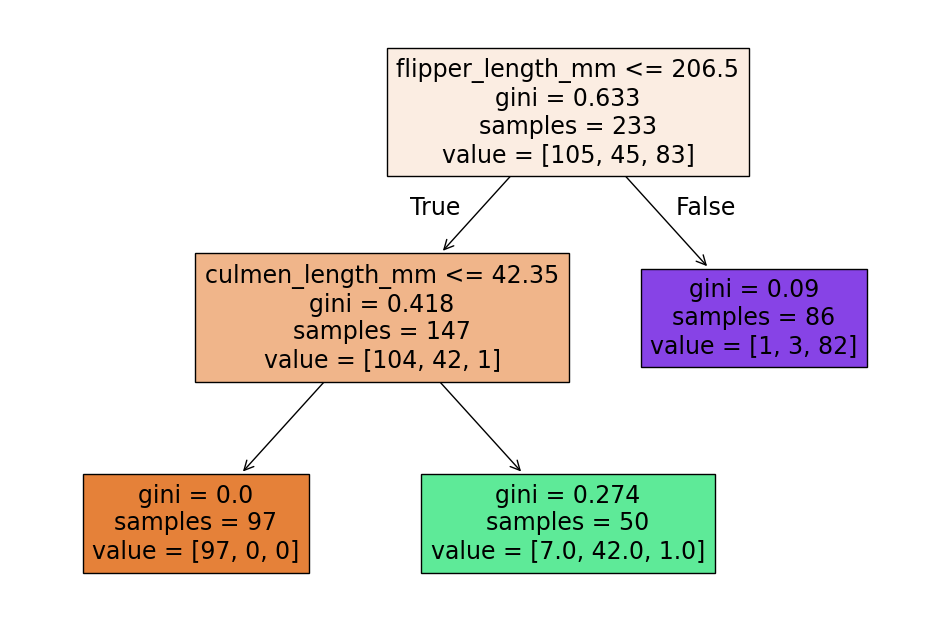

In [134]:
report_result(pruned_tree)

#### *  In general we use Grid Search 

In [136]:
# Note : we have seen Gini impurity. There is other metric called entropy. 

####  Criterion
# Entropy 

              precision    recall  f1-score   support

      Adelie       0.93      0.98      0.95        41
   Chinstrap       0.95      0.87      0.91        23
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.96       101
   macro avg       0.96      0.95      0.95       101
weighted avg       0.96      0.96      0.96       101





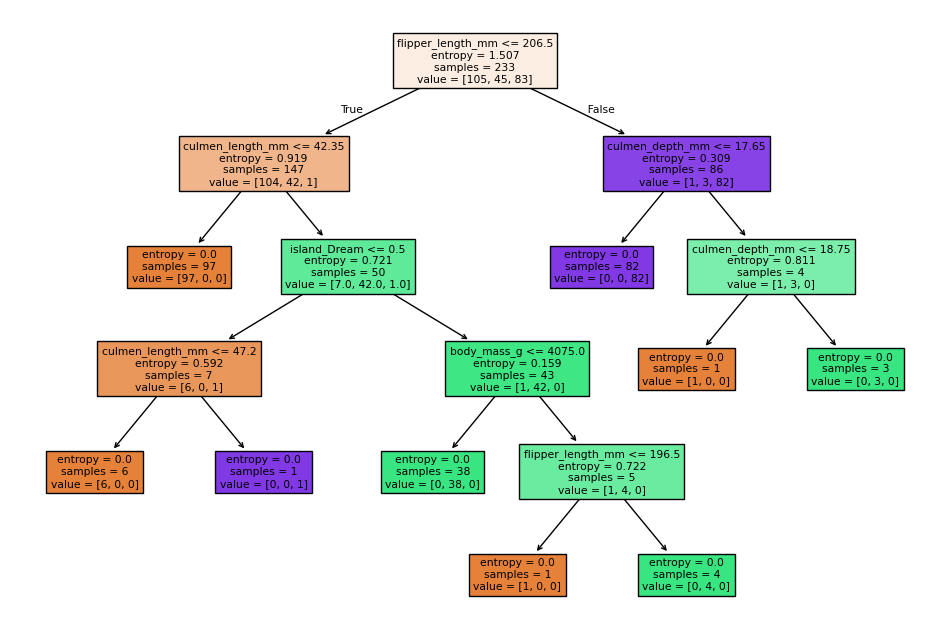

In [137]:
e_model = DecisionTreeClassifier(criterion="entropy")
e_model.fit(X_train, y_train)
report_result(e_model)